
 Mediana del peso de los productos: 12.6

 Moda del peso de los productos: 12.15 con frecuencia: 86

 Cantidad de productos filtrados: 60

 Diferencia entre precio y ventas para los primeros 10 productos:


Precio,Ventas,Diferencia
249.8092,3735.1380,-3485.3288
48.2692,443.4228,-395.1536
141.6180,2097.2700,-1955.6520
182.0950,732.3800,-550.2850
53.8614,994.7052,-940.8438
51.4008,556.6088,-505.2080
57.6588,343.5528,-285.8940
107.7622,4022.7636,-3915.0014
96.9726,1076.5986,-979.6260
187.8214,4710.5350,-4522.7136



 Visibilidad Original y Normalizada (primeros 10 valores):


Visibilidad Original,Visibilidad Normalizada
0.016047,0.048866
0.019278,0.058705
0.016760,0.051037
0.000000,0.000000
0.000000,0.000000
0.000000,0.000000
0.012741,0.038799
0.127470,0.388165
0.016687,0.050815
0.094450,0.287613



 Media por columna (peso, precio, ventas):


...


 Cantidad de productos con peso faltante: 1463


Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
DRI11,NaN,Low Fat,0.034238,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.6680
FDW12,NaN,Regular,0.035400,Baking Goods,144.5444,OUT027,1985,Medium,Tier 3,Supermarket Type3,4064.0432
FDC37,NaN,Low Fat,0.057557,Baking Goods,107.6938,OUT019,1985,Small,Tier 1,Grocery Store,214.3876
FDC14,NaN,Regular,0.072222,Canned,43.6454,OUT019,1985,Small,Tier 1,Grocery Store,125.8362
FDV20,NaN,Regular,0.059512,Fruits and Vegetables,128.0678,OUT027,1985,Medium,Tier 3,Supermarket Type3,2797.6916
FDX10,NaN,Regular,0.123111,Snack Foods,36.9874,OUT027,1985,Medium,Tier 3,Supermarket Type3,388.1614
FDB34,NaN,Low Fat,0.026481,Snack Foods,87.6198,OUT027,1985,Medium,Tier 3,Supermarket Type3,2180.4950
FDS02,NaN,Regular,0.255395,Dairy,196.8794,OUT019,1985,Small,Tier 1,Grocery Store,780.3176
FDI26,NaN,Low Fat,0.061082,Canned,180.0344,OUT019,1985,Small,Tier 1,Grocery Store,892.1720



 Precios simulados (primeros 10):


Precios Simulados
195.970418
208.212450
214.890545
186.466787
123.178834
184.395082
195.027664
259.835126
223.488441
210.398164



 Correlación entre precios y ventas: 0.5675744466569195


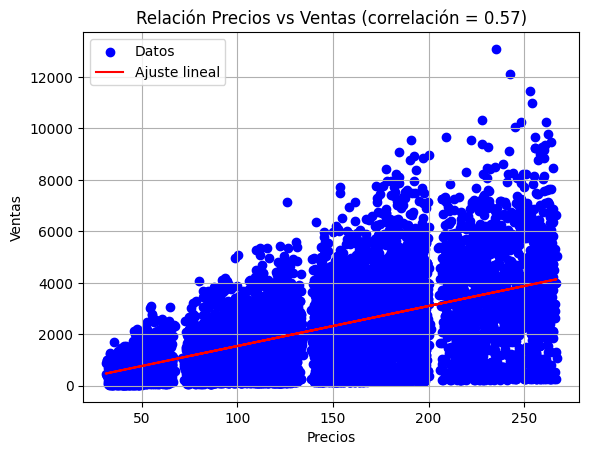


 Precios redondeados (primeros 10):


Precios Redondeados
249.81
48.27
141.62
182.10
53.86
51.40
57.66
107.76
96.97
187.82


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("market.csv")
pesos = df["Item_Weight"].to_numpy()
ventas = df["Item_Outlet_Sales"].to_numpy()
precios = df["Item_MRP"].to_numpy()
visibilidad = df["Item_Visibility"].to_numpy()

# Calcular la mediana del peso de los productos usando NumPy.
print("\n Mediana del peso de los productos:", np.nanmedian(pesos))

# ¿Cuál es el valor más frecuente (moda) de `Item_Weight`?
from scipy import stats
moda = stats.mode(pesos, nan_policy='omit')
print("\n Moda del peso de los productos:", moda.mode, "con frecuencia:", moda.count)

# Filtrar los productos que tengan un precio mayor a $250 y visibilidad menor al 0.02
filtro = (df["Item_MRP"] > 250) & (df["Item_Visibility"] < 0.02)
productos_filtrados = df.loc[filtro].dropna(subset=["Item_MRP", "Item_Visibility"] )
print("\n Cantidad de productos filtrados:", productos_filtrados.shape[0])
productos_filtrados.head(10)

# Crear un array que contenga la diferencia entre el precio y las ventas para los primeros 500 productos.
print("\n Diferencia entre precio y ventas para los primeros 10 productos:")
diferencia = precios[:500] - ventas[:500]
diferencia_df = pd.DataFrame({
    'Precio': precios[:500],
    'Ventas': ventas[:500],
    'Diferencia': diferencia
})
display(HTML(diferencia_df.head(10).to_html(index=False)))

# Normalizar los valores de visibilidad entre 0 y 1.
print("\n Visibilidad Original y Normalizada (primeros 10 valores):")
normalizada = (visibilidad - visibilidad.min()) / (visibilidad.max() - visibilidad.min())
display(HTML(pd.DataFrame({
    'Visibilidad Original': visibilidad[:10],
    'Visibilidad Normalizada': normalizada[:10]
}).to_html(index=False)))

# Crear una matriz de 3 columnas: peso, precio y ventas, y calcular su media por columna.
matriz = np.column_stack((np.mean(pesos, where=~np.isnan(pesos)), np.mean(precios, where=~np.isnan(precios)), np.mean(ventas, where=~np.isnan(ventas))))
print("\n Media por columna (peso, precio, ventas):")
display(HTML(pd.DataFrame(matriz, columns=['Peso', 'Precio', 'Ventas']).to_html(index=False)))

# ¿Qué productos tienen un valor de peso faltante (`NaN`)? ¿Cuántos hay?
productos_nan = df[df["Item_Weight"].isna()]
print("\n Cantidad de productos con peso faltante:", productos_nan.shape[0])
display(HTML(productos_nan.head(10).to_html(index=False)))

# Simular 100 precios aleatorios con `np.random.normal(media,desvio,muestra)` con media 200 y desvío 30.
print("\n Precios simulados (primeros 10):")
precios_simulados = np.random.normal(200, 30, 100)
display(HTML(pd.DataFrame({
    'Precios Simulados': precios_simulados[:10]
}).to_html(index=False)))

# Calcular la correlación entre precios y ventas (usando `np.corrcoef`)
correlacion = np.corrcoef(precios, ventas)[0,1]
print("\n Correlación entre precios y ventas:", correlacion)
plt.scatter(precios, ventas, color="blue", label="Datos")

# Línea de ajuste lineal
z = np.polyfit(precios, ventas, 1)  # Ajuste de grado 1 (recta)
p = np.poly1d(z)
plt.plot(precios, p(precios), color="red", label="Ajuste lineal")

# Personalizar gráfico
plt.title(f"Relación Precios vs Ventas (correlación = {correlacion:.2f})")
plt.xlabel("Precios")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

# Guardar un nuevo array con los precios redondeados a 2 decimales
precios_redondeados = np.round(precios, 2)
print("\n Precios redondeados (primeros 10):")
display(HTML(pd.DataFrame({
    'Precios Redondeados': precios_redondeados[:10]
}).to_html(index=False)))